# MAB button-pushing — analysis
Load a list of `results.json` files produced by `run.py` (the shared baselines file plus one `results_<temperature>.json` per model) and compare all models against the classic baselines on the same plots.
Headline metric is **cumulative regret** against the (possibly moving) optimum; also shown are average reward and parse-failure rate.

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import metrics

# List every results file to compare. Baselines live in their own file (run.py baseline);
# each model writes results_<temperature>.json. Their agent keys don't collide, so we
# merge them into one dict and every plot below overlays all of them.
RESULTS = [
    './data/outputs/baselines/results.json',
    './data/outputs/gemma4_e2b/results_1.0.json',
    # './data/outputs/qwen3_4b/results_0.7.json',
    './data/outputs/llama3.2_3b/results_1.0.json',
    './data/outputs/granite4.1_3b/results_1.0.json',
]

agents = {}
for path in RESULTS:
    p = Path(path)
    if not p.exists():
        print(f"skip (missing): {path}")
        continue
    agents.update(json.loads(p.read_text())['agents'])

print('agents:', list(agents))
for name, d in agents.items():
    print(f"{name:16s}", d['metrics'])

skip (missing): ./data/outputs/gemma4_e2b/results_2.0.json
skip (missing): ./data/outputs/qwen3_4b/results_0.7.json
skip (missing): ./data/outputs/llama3.2_3b/results_1.0.json
skip (missing): ./data/outputs/granite4.1_3b/results_0.0.json
agents: ['ucb', 'greedy', 'thompson']
ucb              {'n_trajectories': 20, 'horizon': 1000, 'final_avg_reward': 0.56265, 'final_cumulative_regret': 36.53, 'final_cumulative_regret_se': 1.8274673299693545, 'parse_failure_rate': 0.0}
greedy           {'n_trajectories': 20, 'horizon': 1000, 'final_avg_reward': 0.5205499999999998, 'final_cumulative_regret': 81.37999999999889, 'final_cumulative_regret_se': 22.144610369591934, 'parse_failure_rate': 0.0}
thompson         {'n_trajectories': 20, 'horizon': 1000, 'final_avg_reward': 0.5716, 'final_cumulative_regret': 27.429999999999957, 'final_cumulative_regret_se': 1.7600403703503988, 'parse_failure_rate': 0.0}


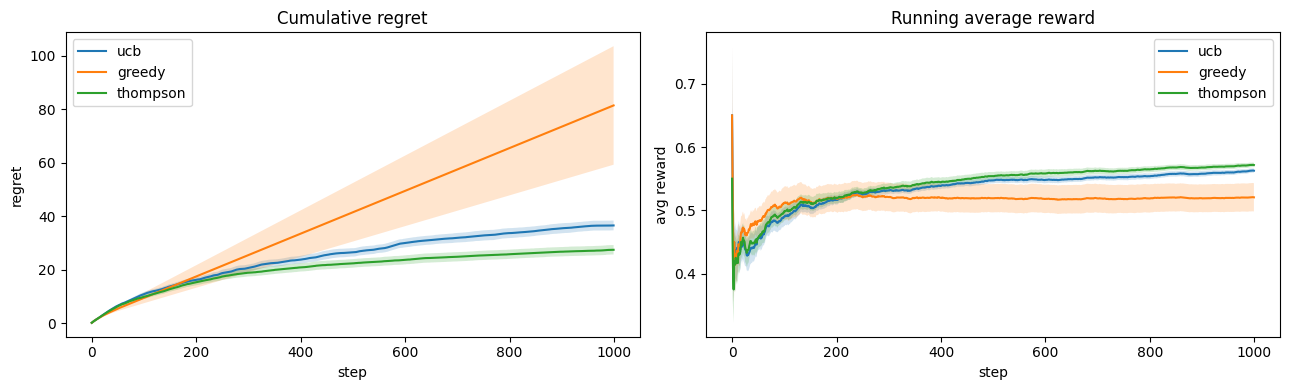

In [2]:
# Cumulative regret (headline) and running average reward
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for name, d in agents.items():
    trajs = d['trajectories']
    reg_mean, reg_se = metrics.cumulative_regret_curve(trajs)
    rew_mean, rew_se = metrics.average_reward_curve(trajs)
    x = range(len(reg_mean))
    ax1.plot(x, reg_mean, label=name)
    ax1.fill_between(x, reg_mean - reg_se, reg_mean + reg_se, alpha=0.2)
    ax2.plot(x, rew_mean, label=name)
    ax2.fill_between(x, rew_mean - rew_se, rew_mean + rew_se, alpha=0.2)
ax1.set(title='Cumulative regret', xlabel='step', ylabel='regret'); ax1.legend()
ax2.set(title='Running average reward', xlabel='step', ylabel='avg reward'); ax2.legend()
plt.tight_layout(); plt.show()

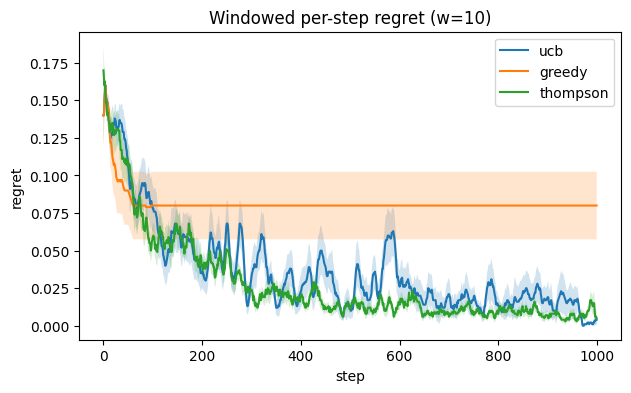

In [3]:
# Windowed (instantaneous) regret — preferred once means drift (non-stationary runs)
plt.figure(figsize=(7, 4))
for name, d in agents.items():
    mean, se = metrics.instantaneous_regret_curve(d['trajectories'], window=10)
    x = range(len(mean))
    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - se, mean + se, alpha=0.2)
plt.title('Windowed per-step regret (w=10)'); plt.xlabel('step'); plt.ylabel('regret')
plt.legend(); plt.show()

## Optimal-arm selection over the horizon
Where each agent actually pulls the true best arm. `regret == 0` marks an optimal pull (works for the LLM and the baselines).
- **Raster**: one panel per agent, one row per trajectory, a marker at every step where the optimal arm was picked.
- **Curve**: fraction of trajectories picking optimal at each step (with stderr band), all agents overlaid.

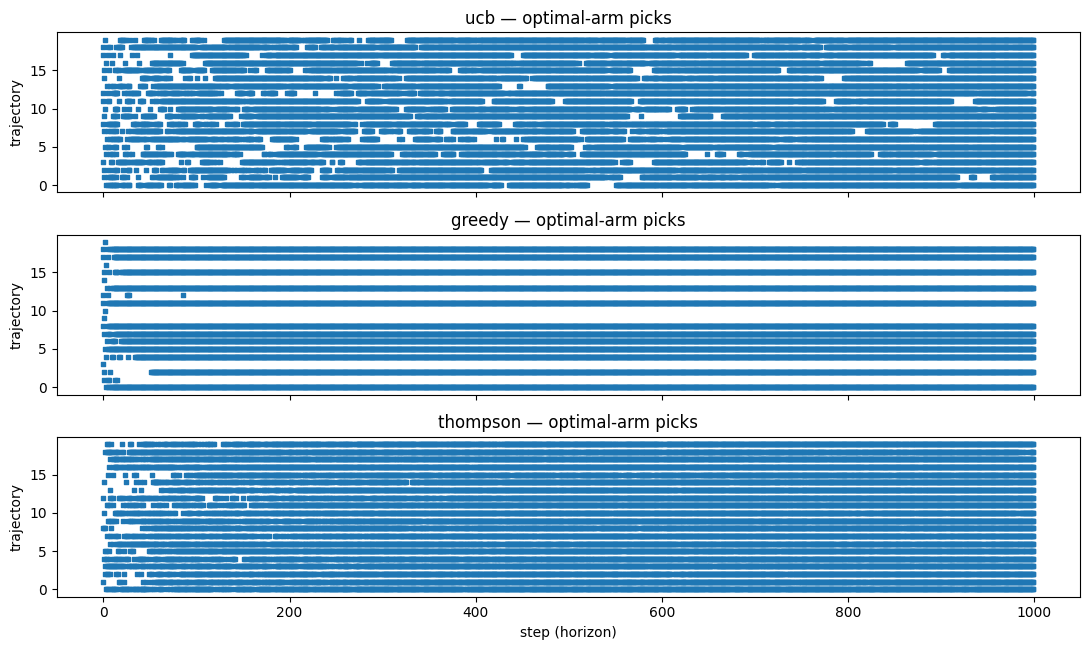

In [4]:
# Raster: a marker at every (step, trajectory) where the optimal arm was picked
import numpy as np
n = len(agents)
fig, axes = plt.subplots(n, 1, figsize=(11, 2.2 * n), sharex=True)
axes = np.atleast_1d(axes)
for ax, (name, d) in zip(axes, agents.items()):
    opt = metrics._optimal_matrix(d['trajectories'])   # (n_trajs, horizon) bool
    ys, xs = np.where(opt)                              # marker only where optimal
    ax.scatter(xs, ys, s=6, marker='s')
    ax.set(ylabel='trajectory', title=f'{name} — optimal-arm picks')
axes[-1].set_xlabel('step (horizon)')
plt.tight_layout(); plt.show()

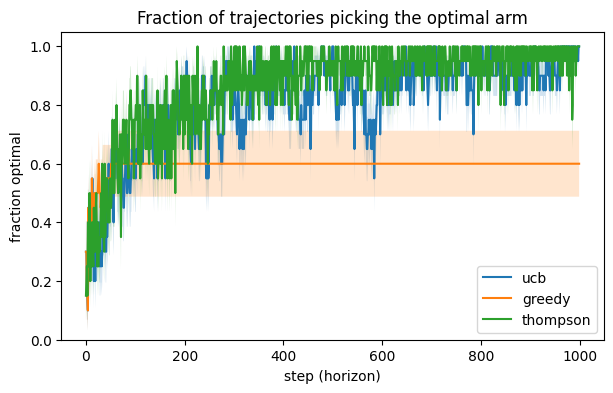

In [5]:
# Fraction of trajectories picking the optimal arm at each step (all agents overlaid)
plt.figure(figsize=(7, 4))
for name, d in agents.items():
    mean, se = metrics.optimal_action_rate_curve(d['trajectories'])
    x = range(len(mean))
    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - se, mean + se, alpha=0.2)
plt.title('Fraction of trajectories picking the optimal arm')
plt.xlabel('step (horizon)'); plt.ylabel('fraction optimal'); plt.ylim(0, 1.05)
plt.legend(); plt.show()